In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg.potential_fields import magnetics
from pathlib import Path
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

import sys
sys.path.append("../src")

import init_utils

In [2]:
#Fix path to data directory
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

### Read in Data

In [3]:
#Read in data
observations = init_utils.read_obs_mag("obs.mag")
topography = init_utils.read_topo("topo.dat")
mesh_data = init_utils.read_tensor_mesh(DATA_DIR / "sus.msh")

x_topo = topography['X'].values
y_topo = topography['Y'].values
z_topo = topography['Z'].values

topo_xyz = np.c_[x_topo, y_topo, z_topo]

### Define receiver locations

In [4]:
# Define obervation locations

#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x_obs = observations['X'].values
y_obs = observations['Y'].values

fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z_obs = fun_interp(np.c_[x_obs, y_obs])  

mask = ~np.isnan(z_obs) #be careful of NANs from the interpolation
receiver_locations_initial = np.c_[x_obs[mask], y_obs[mask], z_obs[mask]] 


# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations_initial, components=components) #List of receivers from locations
receiver_list = [receiver_list]

### Define Survey

In [5]:
# Define the inducing field
inclination = 75  # inclination [deg]
declination = 25.73  # declination [deg]
amplitude = 58193  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

### Define the mesh

In [ ]:
nx, ny, nz = mesh_data["nx"], mesh_data["ny"], mesh_data["nz"]
dx, dy, dz = mesh_data["dx"], mesh_data["dy"], mesh_data["dz"]
x0, y0, z0 = mesh_data["x0"], mesh_data["y0"], mesh_data["z0"]

x_mesh = [(dx, 5, -1.3), (dx, nx), (dx, 5, 1.3)] 
y_mesh = [(dy, 5, -1.3), (dy, ny), (dy, 5, 1.3)]
z_mesh = [(dz, 5, -1.3), (dz, nz)]

tensor_mesh = TensorMesh([x_mesh, y_mesh, z_mesh], "CCN")

hx, hy, hz = tensor_mesh.h

tensor_mesh.origin = np.r_[
    x0 - np.sum(hx[:5]),
    y0 - np.sum(hy[:5]),
    z0 - np.sum(hz),
]

### Define active cells and mapping

In [7]:
#By active cells, we mean the cells that are below the topography. Air cells should not have a suceptibility value.
# Indices of the active mesh cells from topography (e.g. cells below surface), boolenans
active_cells = active_from_xyz(tensor_mesh, topo_xyz) #simpeg function

# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map

# Define simulation

In [8]:
initial_simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

### Define data and errors
Filtering Nan's from earlier interpolation

In [9]:
dobs_full = observations['MAG'].values
errors_full = observations['ERR'].values
dobs = dobs_full[mask]
errors = errors_full[mask]

# detect and drop bad dpred point 
starting_tensor_model = 1e-4 * np.ones(n_active)

dpred0 = initial_simulation.dpred(starting_tensor_model)
good = ~np.isnan(dpred0)

# Filter receivers and data
receiver_locations_good = receiver_locations_initial[good]
dobs_good = dobs[good]
errors_good = errors[good]

# Rebuild receiver list, source field, survey
receiver_list = magnetics.receivers.Point(
    receiver_locations_good, components=["tmi"]
)
source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[receiver_list],
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)
survey = magnetics.survey.Survey(source_field)

# Rebuild simulation with cleaned survey
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

# Replace dobs/errors with cleaned versions
dobs = dobs_good
errors = errors_good

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Equivalent source simulation

In [10]:
# 1. Define the Height Shift
z_lift = 20.0  # The total height you want to shift data to

# 2. Create the "Equivalent Source" Simulation
# We simulate a thin layer of cells just below the topography
# to capture the signal without a full 3D inversion.

# Find the "top" layer of the active cells
# We can do this by finding the highest active cell in every x,y column
# Or more simply: just pick cells within one cell-height (dz) of the surface


# This utility finds the indices of the very top layer of active cells
# 1. Get the cell centers of all cells
cc = tensor_mesh.gridCC

# 2. Get the centers of ONLY the active cells
active_cc = cc[active_cells]

# 3. We want the highest cell (max Z) for every unique (X, Y)
# We can use a pandas groupby or a simple loop. Since your mesh is structured:

# Create a dataframe of active cell centers and their original indices
df_active = pd.DataFrame(active_cc, columns=['x', 'y', 'z'])
df_active['original_index'] = np.where(active_cells)[0]

# Group by X and Y, and find the index where Z is maximum
# This identifies the "skin" of the earth (We are taking 1 cell beelow the surface)
surf_layer_inds = df_active.sort_values('z').groupby(['x', 'y']).nth(-2)['original_index'].values

# Now proceed with the rest of your code:
eq_active_cells = np.zeros(tensor_mesh.n_cells, dtype=bool)
eq_active_cells[surf_layer_inds.astype(int)] = True

n_eq_active = int(eq_active_cells.sum())
eq_model_map = maps.IdentityMap(nP=n_eq_active)

# Use existing topography and survey setup
eq_receiver_list = magnetics.receivers.Point(receiver_locations_good, components=["tmi"])
eq_source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[eq_receiver_list],
    amplitude=amplitude, inclination=inclination, declination=declination
)
eq_survey = magnetics.survey.Survey(eq_source_field)

# Use a very simple mesh for the layer: just the top of your existing tensor_mesh
# or use the Integral simulation directly on active_cells restricted to the surface
eq_simulation = magnetics.simulation.Simulation3DIntegral(
    survey=eq_survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=eq_model_map,
    active_cells=eq_active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)


Upward_continuation_start_model = 1e-4 * np.ones(n_eq_active)
Up_cont_reference_model = np.zeros_like(Upward_continuation_start_model)

# 3. Run a quick L2 inversion to get the "Equivalent Model"
# Note: We use a high alpha_s (smallness) to keep it near the surface
eq_data_obj = data.Data(eq_survey, dobs=dobs, standard_deviation=errors)
eq_misfit = data_misfit.L2DataMisfit(data=eq_data_obj, simulation=eq_simulation)
eq_reg = regularization.WeightedLeastSquares(tensor_mesh, active_cells=eq_active_cells, 
                                             reference_model= Up_cont_reference_model,
                                            alpha_s=1e-4,# Smallness
                                            alpha_x=0.5,  # We don't care about smoothness for an eq source
                                            alpha_y=0.5,
                                            alpha_z=0.5)

# Removed lower bound, bc we do not something physically meaningful, 
# just want to fit the data with a thin layer. 
eq_opt = optimization.ProjectedGNCG(maxIter=50, lower = 0.0) 

eq_inv_prob = inverse_problem.BaseInvProblem(eq_misfit, eq_reg, eq_opt)

eq_beta = directives.BetaEstimate_ByEig(beta0_ratio=1e-4)  #Super small beta, focus on misfit only
target = directives.TargetMisfit(chifact=1.0) #Run inversion until it actually fits data to thin layer

eq_inv = inversion.BaseInversion(eq_inv_prob, [eq_beta, target])


# This model just needs to recreate your ground data
m_eq = eq_inv.run(Upward_continuation_start_model)

# 4. Predict data at the new height (20m lift)
new_locs = receiver_locations_good.copy()
new_locs[:, 2] += z_lift 

up_receiver_list = magnetics.receivers.Point(new_locs, components=["tmi"])
up_source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[up_receiver_list],
    amplitude=amplitude, inclination=inclination, declination=declination
)
up_survey = magnetics.survey.Survey(up_source_field)

up_sim = magnetics.simulation.Simulation3DIntegral(
    survey=up_survey, mesh=tensor_mesh, chiMap=eq_model_map, 
    active_cells=eq_active_cells, model_type="scalar"
)

# This is your new "dobs" for the real 3D inversion
dobs_upward_continued = up_sim.dpred(m_eq)

/var/folders/3d/yf36xnp966v6l9x5ngg5879w0000gn/T/ipykernel_9128/2802313979.py:75: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  eq_opt = optimization.ProjectedGNCG(maxIter=50, lower = 0.0)
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver SolverLU with the 'is_symmetric=True` option set.

/Users/jackson/miniconda3/envs/EOSC454-Project/lib/python3.11/site-packages/pymatsolver/wrappers.py:79: UnusedArgumentWarning: Unused keyword argument "is_symmetric" for splu.
  self.kwargs = kwargs
/Users/jackson/miniconda3/envs/EOSC454-Project/lib/python3.11/site-packages/pymatsolver/wrappers.py:81: SparseEfficiencyWarning: splu converted its input to CSC format
  self.solver = fun(self.A, **self.kwargs)



Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 2009.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.11e+01  1.28e+05  3.55e-05  1.28e+05                         0           inf          inf                
   1  1.11e+01  7.81e+04  1.51e+00  7.81e+04    8.80e+04      0      5        1.51e+00     1.95e+05              
   2  1.11e+01  5.95e+04  9.12e+00  5.96e+04    7.29e+04      0      5        3.46e+00     2.78e+05   Skip BFGS  
   3  1.11e+01  3.78e+04  8.61e+00  3.79e+04    9.34e+04      0      5        3.64e-01     6.99e+04              
   4  1.11e+01  2.63e+04  1.60e+01  2.65e+04    5.02e+04      0      5        1.31e+00     6.18e+04              
   5  1.11e+01  1.93e+04  1.70e+01  1.95e+04    9.31e+04      0      5        5.16e-01 

### Visualize Results

[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/figures/Raw_and_Up_Data.png


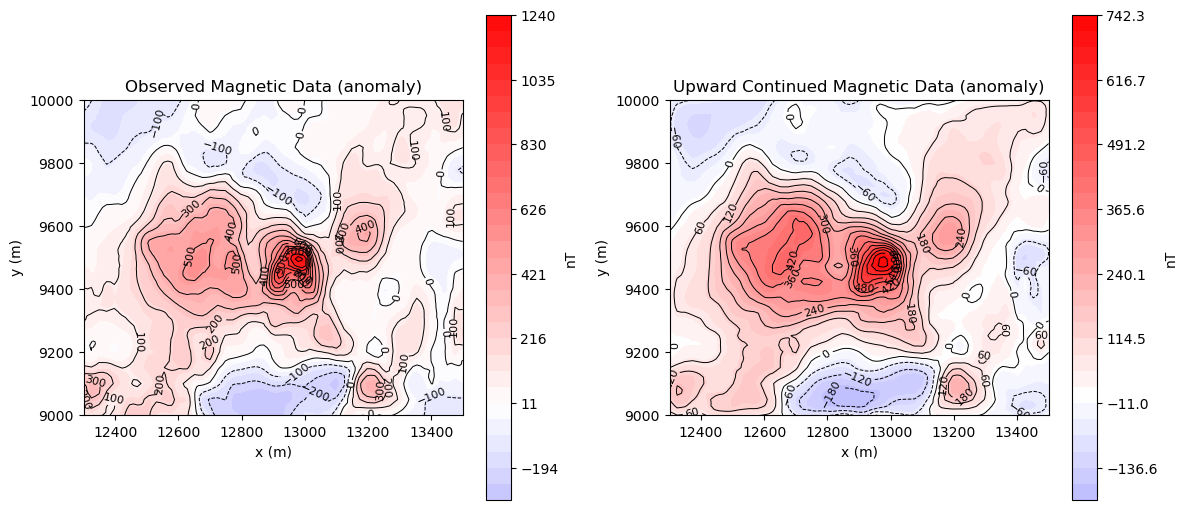

In [13]:
fig, ax = plt.subplots(1,2, figsize=(12, 10))
data_list = [dobs, dobs_upward_continued]
titles = ["Observed Magnetic Data (anomaly)", "Upward Continued Magnetic Data (anomaly)"]

for i, (data, title) in enumerate(zip(data_list, titles)):
     
    # Symmetric color scale
    vmax = np.max(np.abs(data))
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

    # --- Filled contours (SimPEG) ---
    cplot = plot2Ddata(
        receiver_locations_good[:, :2],
        data,
        ax=ax[i],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm},
    )

    # --- Interpolate to grid for contour lines ---
    from scipy.interpolate import griddata

    x = receiver_locations_good[:, 0]
    y = receiver_locations_good[:, 1]

    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((x, y), data, (Xi, Yi), method="linear")

    # --- Solid contour lines ---
    cs = ax[i].contour(
        Xi, Yi, Zi,
        levels=15,
        colors="k",
        linewidths=0.7
    )

    # Optional: label contours
    ax[i].clabel(cs, inline=True, fontsize=8)

    # Titles and labels
    ax[i].set_title(title)
    ax[i].set_xlabel("x (m)")
    ax[i].set_ylabel("y (m)")

    # Colorbar
    cbar = plt.colorbar(cplot[0], ax=ax[i], shrink=0.5)
    cbar.set_label("nT")

plt.tight_layout()
init_utils.save_figure('Raw_and_Up_Data')
plt.show()


### Cache arrays

In [12]:
# init_utils.save_cache(
#     "upward_data",
#     dobs= dobs_upward_continued,
#     errors= errors_good,
# )

# init_utils.save_cache(
#     "survey_info",
#     receivers= new_locs,
#     amplitude=amplitude,
#     inclination=inclination,
#     declination=declination,
# )

# init_utils.save_cache(
#     "topo_and_active",
#     active_cells= active_cells,
#     topography= topo_xyz,
# )